# ROC & AUC

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# tumor size (X)
X = [
    [7], [2], [9], [4], [6], [1], [10], [5], [8], [3],
    [6], [9], [2], [7], [4], [10], [1], [8], [5], [6],
    [3], [7], [10], [2], [9], [4], [8], [1], [6], [5],
    [10], [3], [7], [2], [8], [6], [4], [9], [1], [10],
    [5], [8], [2], [6], [9], [3], [7], [1], [10], [4],
    [6], [8], [5], [9], [2], [7], [10], [3], [1], [6],
    [4], [9], [8], [2], [10], [5], [7], [3], [6], [1],
    [9], [4], [8], [10], [2], [7], [5], [6], [3], [1],
    [8], [6], [10], [4], [7], [2], [9], [5], [1], [8],
    [6], [3], [10], [7], [4], [2], [9], [1], [5], [8],
    [10], [6], [3], [7], [2], [9], [4], [8], [1], [10],
    [5], [6], [9], [3], [7], [2], [8], [10], [4], [1],
    [6], [5], [9], [7], [3], [10], [2], [8], [4], [6],
    [1], [9], [5], [7], [10], [3], [8], [2], [6], [4],
    [9], [1], [7], [5], [10], [6], [3], [8], [2], [9],
    [4], [7], [1], [10], [5], [6], [8], [3], [9], [2],
    [7], [4], [10], [1], [6], [5], [8], [3], [9], [7],
    [2], [10], [4], [6], [1], [8], [5], [9], [3], [7],
    [10], [2], [6], [4], [8], [1], [9], [5], [7], [3],
    [6], [10], [2], [8], [4], [9], [1], [7], [5], [10]
]

y = [
    1,0,1,0,1,0,1,0,1,0,
    1,1,0,1,0,1,0,1,0,1,
    0,1,1,0,1,0,1,0,1,0,
    1,0,1,0,1,1,0,1,0,1,
    0,1,0,1,1,0,1,0,1,0,
    1,1,0,1,0,1,1,0,0,1,
    0,1,1,0,1,0,1,0,1,0,
    1,0,1,1,0,1,0,1,0,0,
    1,1,1,0,1,0,1,0,0,1,
    1,0,1,1,0,1,0,1,0,1,
    1,1,0,1,0,1,0,1,0,1,
    0,1,1,0,1,0,1,1,0,0,
    1,0,1,1,0,1,0,1,0,1,
    0,1,0,1,1,0,1,0,1,0,
    1,0,1,0,1,0,1,0,1,1,
    0,1,0,1,0,1,0,1,1,0,
    1,0,1,0,1,1,0,1,0,1,
    0,1,0,1,1,0,1,0,1,0,
    1,0,1,0,1,0,1,0,1,1,
    0,1,0,1,0,1,0,1,0,1
]

df = pd.DataFrame({
    "X": [x[0] for x in X],
    "y": y
})

X_train , X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LogisticRegression()

model.fit(X_train, y_train)

input_size = float(input("Enter tumor size in cm: "))
result = model.predict([[input_size]])[0]
proba = model.predict_proba([[input_size]])
label = "Cancerous" if result == 1 else "Not Cancerous"
print(f"Tumor size {input_size} cm, prediction: {label}")
print("Probability:")
print("Safe %:", proba[0][0] * 100)
print("Risk %:", proba[0][1] * 100)



Tumor size 5.0 cm, prediction: Not Cancerous
Probability:
Safe %: 55.75394895471858
Risk %: 44.24605104528142


ROC = Receiver Operating Characteristic curve

TPR = Actual positive cases mein se model ne kitne correctly positive identify kiye?
FPR = Jo actually negative hain, un mein se kitne model ne galti se positive predict kar diye? 

hum confusion matric nikalte hain os se hum TPR Or FPR nikalte hain 

or ROC curve mean TPR or FPR ka graph mean Y-axis pr TPR or X-asix pr FPR 

asal hum alag alag thershold detay hain jis se hum graph dekh pata chal jata hain konsa thrshold sai hain mean jaha hain graph crave hor sida ja raha ho manly os point ko sai thershold mana jata hain 

ROC ka main purpose ye dekhna hai ke different thresholds par model kitna acha positive aur negative cases ko separate kar raha hai.



[       inf 0.97218569 0.94251136 0.78294119 0.62851551 0.44246051
 0.27126424 0.14864687 0.07569785 0.03699325]


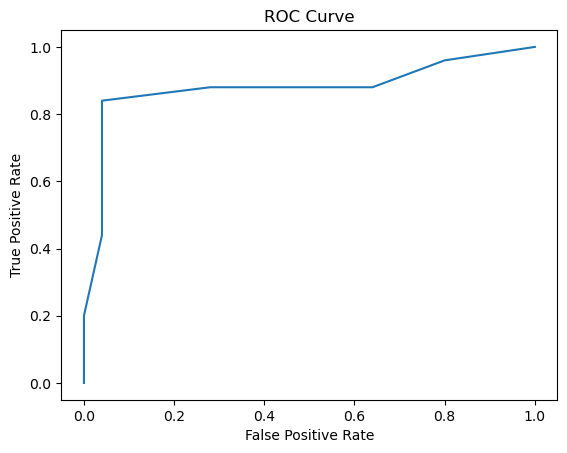

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(thresholds)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [ ]:
# grpah main hum dekh sakte hain point y .84 pr hain or x .04 pr approx tu ab is point pr kona threshold a raha hain ya nichy os tariq hai is ky ab best thresholds nikal skakte hain 


import numpy as np
J = tpr - fpr
best_idx = np.argmax(J)

print("Best Threshold:", thresholds[best_idx])
print("TPR:", tpr[best_idx])
print("FPR:", fpr[best_idx])


Best Threshold: 0.6285155073739704
TPR: 0.84
FPR: 0.04


In [22]:
# Probability
from sklearn.metrics import confusion_matrix, classification_report
y_prob = model.predict_proba(X_test)[:, 1]

# Best threshold
threshold = 0.6285

# Custom prediction
y_pred = (y_prob >= threshold).astype(int)
print(len(y_pred))
# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


50
[[24  1]
 [ 4 21]]
              precision    recall  f1-score   support

           0       0.86      0.96      0.91        25
           1       0.95      0.84      0.89        25

    accuracy                           0.90        50
   macro avg       0.91      0.90      0.90        50
weighted avg       0.91      0.90      0.90        50



Bilkul — 0.6285 har case mein best nahi hota. Ye sirf tumhare particular model + dataset + chosen criterion ke liye best tha.

Sabse important baat:

"Best threshold" depend karta hai ke tum kya optimize karna chahte ho.
Suppose disease detection hai:

Case 1: Disease miss karna dangerous hai
Tum chahoge TPR/Sensitivity high ho. Isliye threshold kam rakh sakte ho, jaise 0.4.

Result:

Zyada actual patients detect honge ✅
Lekin false positives bhi zyada ho sakte hain ❌
Case 2: False alarm dangerous/expensive hai
Tum chahoge FPR low ho. Threshold higher rakh sakte ho, jaise 0.8.

Result:

False positives kam ✅
Lekin kuch actual positives miss ho sakte hain ❌
Case 3: Dono ka balance chahiye
Youden's J:
J = TPR − FPR

maximize kar sakte ho. Tumhare case mein isi se:
Threshold = 0.6285
TPR       = 0.84
FPR       = 0.04

mila.
Isliye ye yaad rakho:
ROC curve tumhe choices dikhati hai; "best" threshold tumhare problem ke objective se decide hota hai.

Aur ek aur important point: AUC ka best hona aur threshold ka best hona alag concepts hain. AUC poore model ki ranking ability measure karta hai; threshold us model ko actual 0/1 predictions mein convert karne ka cutoff hai.

Agar tum chaho, main tumhe ek example mein threshold 0.3, 0.5, 0.63, 0.8 rakh kar dikha sakta hoon ke TPR/FPR kaise change hote hain — usse ye concept permanently clear ho jayega.


# AUC 
AUC = Area Under the ROC Curve
Yani ROC curve ke neeche jo total area hai, woh AUC hai.
matlb arean under the curve mean curve ky andr jo area a raha hain graph main wo auc hain or ya jitan 1 ky kareeb hoga utna acha hain 

is different model compare karte hain jis ka area kam wo model acha hain 

+----------------+--------------------------------------+
| AUC            | General Interpretation               |
+----------------+--------------------------------------+
| 1.0            | Perfect classifier                   |
| 0.9 – 1.0      | Excellent                            |
| 0.8 – 0.9      | Good                                 |
| 0.7 – 0.8      | Acceptable                           |
| 0.6 – 0.7      | Weak                                 |
| 0.5            | Random guessing                      |
| < 0.5          | Worse than random / ranking reversed |
+----------------+--------------------------------------+


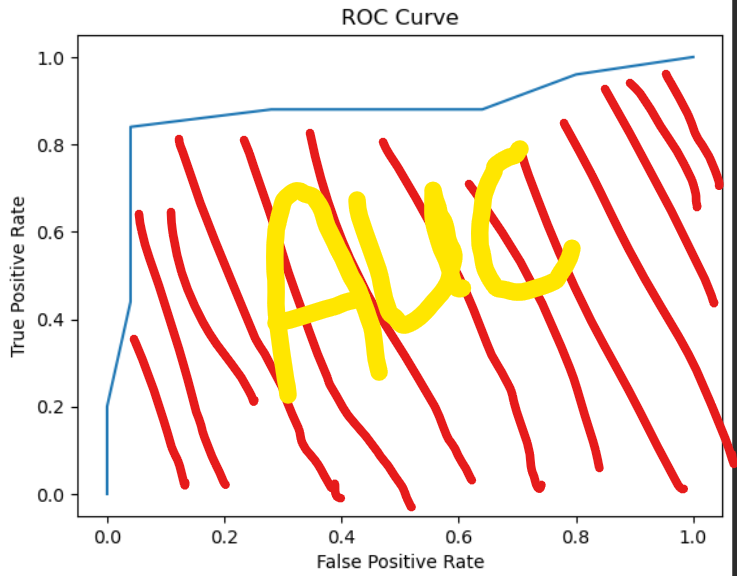

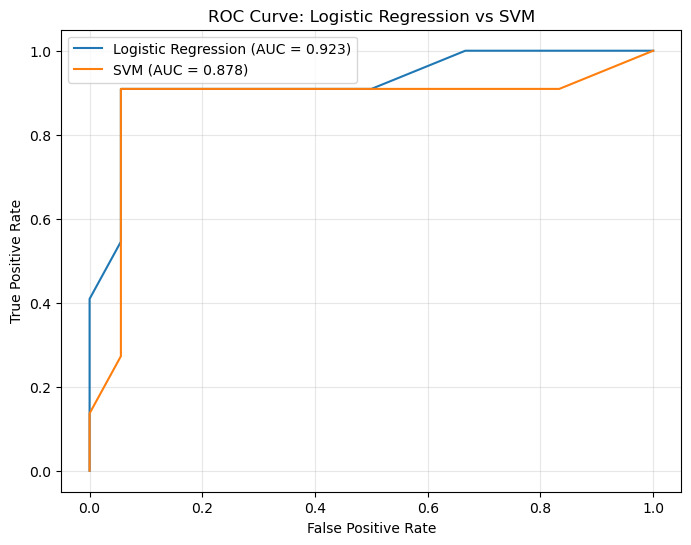

Logistic Regression AUC: 0.922979797979798
SVM AUC: 0.8775252525252525


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score


df = pd.DataFrame({
    "X": [x[0] for x in X],
    "y": y
})

X_data = df[["X"]]
y_data = df["y"]


X_train, X_test, y_train, y_test = train_test_split(X_data,y_data,test_size=0.2,random_state=42,stratify=y_data)


log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_prob = log_model.predict_proba(X_test)[:, 1]


svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)
svm_prob = svm_model.predict_proba(X_test)[:, 1]


log_fpr, log_tpr, log_thresholds = roc_curve(y_test,log_prob)
log_auc = roc_auc_score(y_test,log_prob)


svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test,svm_prob)
svm_auc = roc_auc_score(y_test,svm_prob)


plt.figure(figsize=(8, 6))
plt.plot(log_fpr,log_tpr,label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(svm_fpr,svm_tpr,label=f"SVM (AUC = {svm_auc:.3f})")

# Random classifier line
# plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression vs SVM")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


print("Logistic Regression AUC:", log_auc)
print("SVM AUC:", svm_auc)
